# BRESEQ A. johnsonii output analysis

In [2]:
#IMPORT PACKAGES
import os
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns


## All mutations

In [36]:
#IMPORT OUTPUT DATA FROM BRESEQ

''' Data for Ancestral to the reference genome '''
tables = pd.read_html('/Users/thibaultrosazza/Cluster_mount/AjC6_to_AjAnc/output/index.html')
Ancestral_mut = tables[1]  # This get the Predicted mutations table
Ancestral_mut.tail()

''' Data for BAMix to the reference genome '''
root_dir = '/Users/thibaultrosazza/Cluster_mount/Aj_to_BAMix/'

data_dict = {}

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    
    if os.path.isdir(folder_path):
        index_file = os.path.join(folder_path, 'output', 'index.html')
        
        if os.path.exists(index_file):
            tables = pd.read_html(index_file)
            data_dict[folder_name] = tables[1]           
            print(f"Parsed table from {folder_name}")

BAMix_mut = data_dict

''' Data for BABen60Mix to the reference genome '''
root_dir = '/Users/thibaultrosazza/Cluster_mount/Aj_to_BABen60Mix/'

data_dict = {}

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    
    if os.path.isdir(folder_path):
        index_file = os.path.join(folder_path, 'output', 'index.html')
        
        if os.path.exists(index_file):
            tables = pd.read_html(index_file)
            data_dict[folder_name] = tables[1]           
            print(f"Parsed table from {folder_name}")

BABen60Mix_mut = data_dict

''' Data for BABen60Mono to the reference genome '''
root_dir = '/Users/thibaultrosazza/Cluster_mount/Aj_to_BAMono/'

data_dict = {}

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    
    if os.path.isdir(folder_path):
        index_file = os.path.join(folder_path, 'output', 'index.html')
        
        if os.path.exists(index_file):
            tables = pd.read_html(index_file)
            data_dict[folder_name] = tables[1]           
            print(f"Parsed table from {folder_name}")

BAMono_mut = data_dict

Parsed table from Aj_BA_Mix2_T14
Parsed table from Aj_BA_Mix3_T14
Parsed table from Aj_BA_Mix1_T14
Parsed table from Aj_BA_Mix4_T14
Parsed table from Aj_BA_Mix5_T14
Parsed table from Aj_BA_Mix6_T14
Parsed table from Aj_BA_Mix6_T07
Parsed table from Aj_BA_Mix5_T30
Parsed table from Aj_BA_Mix4_T30
Parsed table from Aj_BA_Mix5_T07
Parsed table from Aj_BA_Mix6_T30
Parsed table from Aj_BA_Mix4_T07
Parsed table from Aj_BA_Mix3_T30
Parsed table from Aj_BA_Mix1_T07
Parsed table from Aj_BA_Mix2_T30
Parsed table from Aj_BA_Mix3_T07
Parsed table from Aj_BA_Mix2_T07
Parsed table from Aj_BA_Mix1_T30
Parsed table from Aj_BA_Mix3_T21
Parsed table from Aj_BA_Mix2_T21
Parsed table from Aj_BA_Mix1_T21
Parsed table from Aj_BA_Mix5_T21
Parsed table from Aj_BA_Mix4_T21
Parsed table from Aj_BA_Mix6_T21
Parsed table from Aj_BABen60_Mix1_T07
Parsed table from Aj_BABen60_Mix2_T30
Parsed table from Aj_BABen60_Mix3_T30
Parsed table from Aj_BABen60_Mix2_T07
Parsed table from Aj_BABen60_Mix1_T30
Parsed table from 

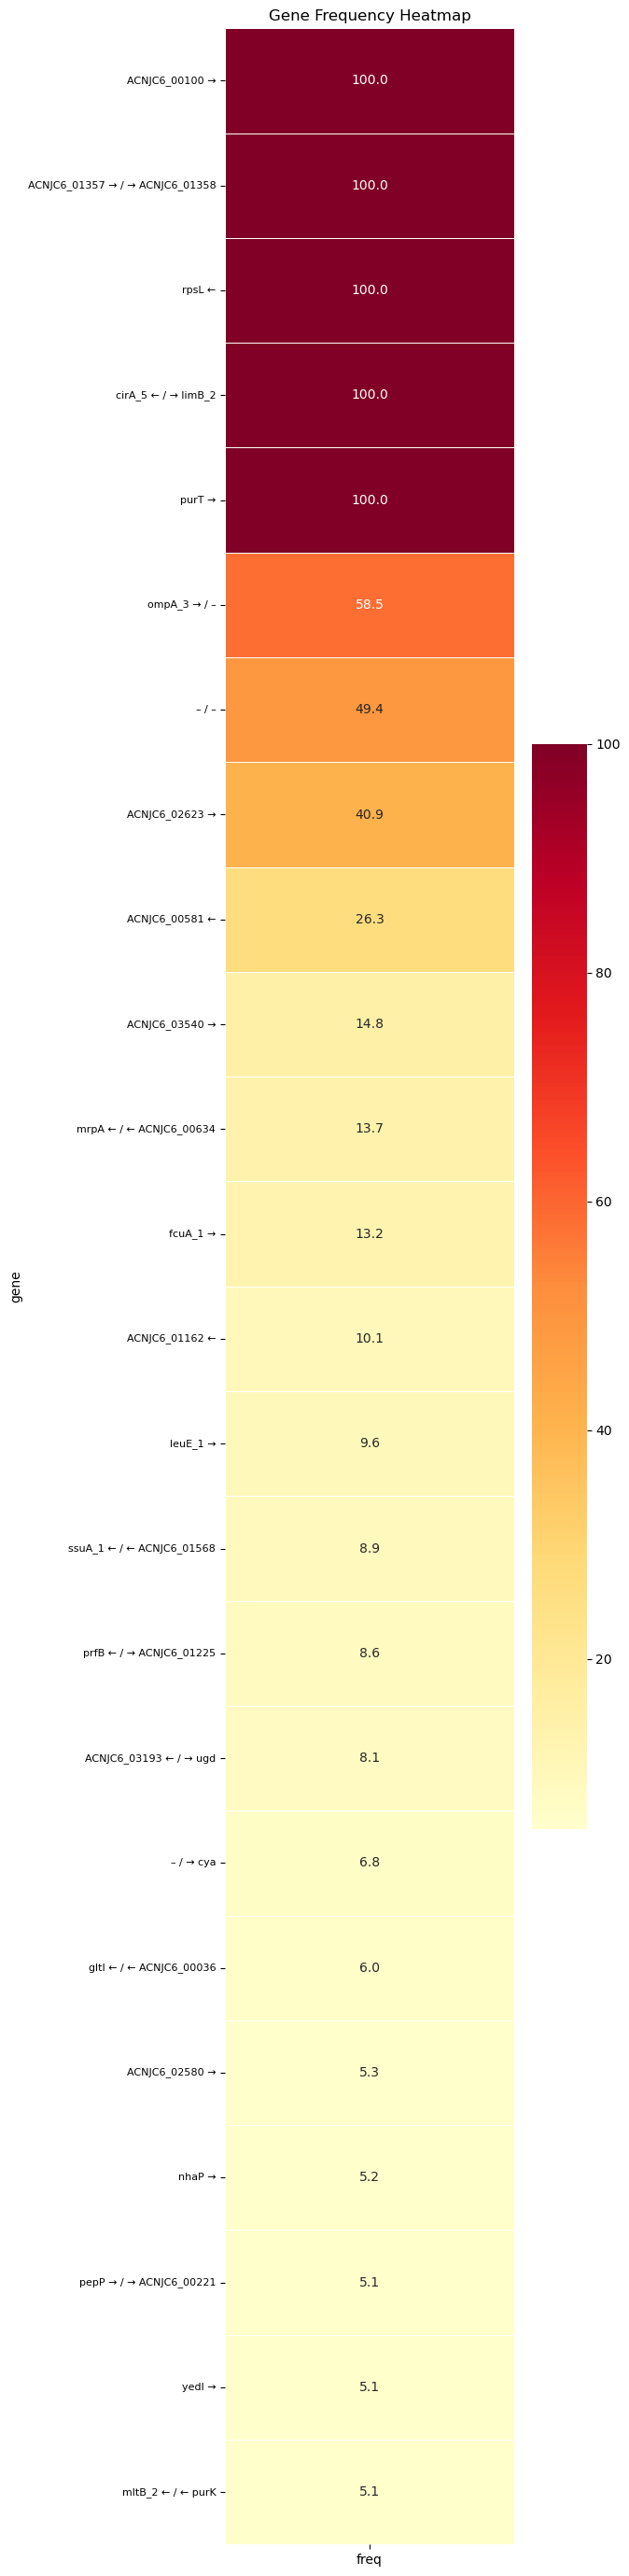

In [37]:
#PLOTTING ANCESTRAL MUTATIONS
df = Ancestral_mut

heatmap_data = pd.DataFrame()
heatmap_data['gene'] = df[('Predicted mutations', 'gene')]
heatmap_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))

#Sort the data by frequency
heatmap_data_sorted = heatmap_data.sort_values(by='freq', ascending=False)
pivot_data = heatmap_data_sorted.pivot_table(index='gene', values='freq')
row_order = pivot_data.sort_values(by='freq', ascending=False).index
pivot_data = pivot_data.loc[row_order]

#Plot
plt.figure(figsize=(5, 35))  # Adjust figure size as needed
sns.heatmap(pivot_data, cmap="YlOrRd", annot=True, fmt=".1f", linewidths=0.5)

plt.yticks(rotation=0)  # Ensure y-axis labels are horizontal
plt.yticks(fontsize=8)  # Adjust font size as needed
plt.title("Gene Frequency Heatmap")  # Add a title

# Show the plot
plt.show()


In [38]:
#MERGING ALL DATA FOR HEATMAP VISUALISATION
ancestral_data = pd.DataFrame()
ancestral_data['gene'] = Ancestral_mut[('Predicted mutations','gene')]
ancestral_data['freq'] = pd.to_numeric(Ancestral_mut[('Predicted mutations','freq')].str.rstrip('%'))
ancestral_data['dataset'] = 'Ancestral'

data_frames = [ancestral_data]

#Iterate through BAMono_mut
for folder, df in BAMono_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)

#Iterate through BABen60Mix_mut
for folder, df in BABen60Mix_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)
    
#Iterate through BAMix_mut
for folder, df in BAMix_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)

# Combine datasets
combined_df = pd.concat(data_frames, ignore_index=True)
combined_df.reset_index(drop=True, inplace=True)

pivot_table = combined_df.pivot_table(index='gene', columns='dataset', values='freq', aggfunc='mean')

desired_order = ['Ancestral',
                 'Aj_BA_Aj1_T07','Aj_BA_Aj1_T14','Aj_BA_Aj1_T21','Aj_BA_Aj1_T30',
                 'Aj_BA_Aj2_T07','Aj_BA_Aj2_T14','Aj_BA_Aj2_T21','Aj_BA_Aj2_T30',
                 'Aj_BA_Aj3_T07','Aj_BA_Aj3_T14','Aj_BA_Aj3_T21','Aj_BA_Aj3_T30',
                 'Aj_BA_Aj4_T07','Aj_BA_Aj4_T14','Aj_BA_Aj4_T21','Aj_BA_Aj4_T30',
                 'Aj_BA_Aj5_T07','Aj_BA_Aj5_T14','Aj_BA_Aj5_T21','Aj_BA_Aj5_T30',
                 'Aj_BA_Aj6_T07','Aj_BA_Aj6_T14','Aj_BA_Aj6_T21','Aj_BA_Aj6_T30',
                 'Aj_BABen60_Mix1_T07','Aj_BABen60_Mix1_T14','Aj_BABen60_Mix1_T21','Aj_BABen60_Mix1_T30',
                 'Aj_BABen60_Mix2_T07','Aj_BABen60_Mix2_T14','Aj_BABen60_Mix2_T21','Aj_BABen60_Mix2_T30',
                 'Aj_BABen60_Mix3_T07','Aj_BABen60_Mix3_T14','Aj_BABen60_Mix3_T21','Aj_BABen60_Mix3_T30',
                 'Aj_BABen60_Mix4_T07','Aj_BABen60_Mix4_T14','Aj_BABen60_Mix4_T21','Aj_BABen60_Mix4_T30',
                 'Aj_BABen60_Mix5_T07','Aj_BABen60_Mix5_T14','Aj_BABen60_Mix5_T21','Aj_BABen60_Mix5_T30',
                 'Aj_BABen60_Mix6_T07','Aj_BABen60_Mix6_T14','Aj_BABen60_Mix6_T21','Aj_BABen60_Mix6_T30',
                 'Aj_BA_Mix1_T07','Aj_BA_Mix1_T14','Aj_BA_Mix1_T21','Aj_BA_Mix1_T30',
                 'Aj_BA_Mix2_T07','Aj_BA_Mix2_T14','Aj_BA_Mix2_T21','Aj_BA_Mix2_T30',
                 'Aj_BA_Mix3_T07','Aj_BA_Mix3_T14','Aj_BA_Mix3_T21','Aj_BA_Mix3_T30',
                 'Aj_BA_Mix4_T07','Aj_BA_Mix4_T14','Aj_BA_Mix4_T21','Aj_BA_Mix4_T30',
                 'Aj_BA_Mix5_T07','Aj_BA_Mix5_T14','Aj_BA_Mix5_T21','Aj_BA_Mix5_T30',
                 'Aj_BA_Mix6_T07','Aj_BA_Mix6_T14','Aj_BA_Mix6_T21','Aj_BA_Mix6_T30'
                ]  
pivot_table = pivot_table[desired_order]

plt.figure(figsize=(50, 200))  # Adjust the figure size as needed
ax = sns.heatmap(pivot_table, cmap="YlOrRd", annot=False, fmt=".1f", linewidths=0.5)

plt.yticks(rotation=0)  
plt.yticks(fontsize=8)
plt.xlabel("dataset")
plt.ylabel("Gene")
plt.title("Gene Frequency Heatmap")

plt.show()

In [39]:
#MERGING ALL DATA FOR HEATMAP VISUALISATION
ancestral_data = pd.DataFrame()
ancestral_data['gene'] = Ancestral_mut[('Predicted mutations','gene')]
ancestral_data['freq'] = pd.to_numeric(Ancestral_mut[('Predicted mutations','freq')].str.rstrip('%'))
ancestral_data['dataset'] = 'Ancestral'

data_frames = [ancestral_data]

#Iterate through BAMono_mut
for folder, df in BAMono_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)

#Iterate through BABen60Mix_mut
for folder, df in BABen60Mix_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)
    
#Iterate through BAMix_mut
for folder, df in BAMix_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)

# Combine datasets
combined_df = pd.concat(data_frames, ignore_index=True)
combined_df.reset_index(drop=True, inplace=True)

pivot_table = combined_df.pivot_table(index='gene', columns='dataset', values='freq', aggfunc='mean')

desired_order = ['Ancestral',
                 'Aj_BA_Aj1_T07','Aj_BA_Aj1_T14','Aj_BA_Aj1_T21','Aj_BA_Aj1_T30',
                 'Aj_BA_Aj2_T07','Aj_BA_Aj2_T14','Aj_BA_Aj2_T21','Aj_BA_Aj2_T30',
                 'Aj_BA_Aj3_T07','Aj_BA_Aj3_T14','Aj_BA_Aj3_T21','Aj_BA_Aj3_T30',
                 'Aj_BA_Aj4_T07','Aj_BA_Aj4_T14','Aj_BA_Aj4_T21','Aj_BA_Aj4_T30',
                 'Aj_BA_Aj5_T07','Aj_BA_Aj5_T14','Aj_BA_Aj5_T21','Aj_BA_Aj5_T30',
                 'Aj_BA_Aj6_T07','Aj_BA_Aj6_T14','Aj_BA_Aj6_T21','Aj_BA_Aj6_T30',
                 'Aj_BABen60_Mix1_T07','Aj_BABen60_Mix1_T14','Aj_BABen60_Mix1_T21','Aj_BABen60_Mix1_T30',
                 'Aj_BABen60_Mix2_T07','Aj_BABen60_Mix2_T14','Aj_BABen60_Mix2_T21','Aj_BABen60_Mix2_T30',
                 'Aj_BABen60_Mix3_T07','Aj_BABen60_Mix3_T14','Aj_BABen60_Mix3_T21','Aj_BABen60_Mix3_T30',
                 'Aj_BABen60_Mix4_T07','Aj_BABen60_Mix4_T14','Aj_BABen60_Mix4_T21','Aj_BABen60_Mix4_T30',
                 'Aj_BABen60_Mix5_T07','Aj_BABen60_Mix5_T14','Aj_BABen60_Mix5_T21','Aj_BABen60_Mix5_T30',
                 'Aj_BABen60_Mix6_T07','Aj_BABen60_Mix6_T14','Aj_BABen60_Mix6_T21','Aj_BABen60_Mix6_T30',
                 'Aj_BA_Mix1_T07','Aj_BA_Mix1_T14','Aj_BA_Mix1_T21','Aj_BA_Mix1_T30',
                 'Aj_BA_Mix2_T07','Aj_BA_Mix2_T14','Aj_BA_Mix2_T21','Aj_BA_Mix2_T30',
                 'Aj_BA_Mix3_T07','Aj_BA_Mix3_T14','Aj_BA_Mix3_T21','Aj_BA_Mix3_T30',
                 'Aj_BA_Mix4_T07','Aj_BA_Mix4_T14','Aj_BA_Mix4_T21','Aj_BA_Mix4_T30',
                 'Aj_BA_Mix5_T07','Aj_BA_Mix5_T14','Aj_BA_Mix5_T21','Aj_BA_Mix5_T30',
                 'Aj_BA_Mix6_T07','Aj_BA_Mix6_T14','Aj_BA_Mix6_T21','Aj_BA_Mix6_T30'
                ] 
pivot_table = pivot_table[desired_order]

# Reorder rows based on the frequency values in the 'Ancestral' dataset
ancestral_freq = pivot_table['Ancestral']
row_order = ancestral_freq.sort_values(ascending=False).index
pivot_table = pivot_table.loc[row_order]

plt.figure(figsize=(50, 200))  # Adjust the figure size as needed
ax = sns.heatmap(pivot_table, cmap="YlOrRd", annot=False, fmt=".1f", linewidths=0.5)

plt.yticks(rotation=0)  
plt.yticks(fontsize=8)
plt.xlabel("dataset")
plt.ylabel("Gene")
plt.title("Gene Frequency Heatmap")

plt.savefig('/Users/thibaultrosazza/Documents/Python/Results/Evolution_experiment/AllMut_Aj_heatmap.png', dpi=300)
plt.savefig('/Users/thibaultrosazza/Documents/Python/Results/Evolution_experiment/AllMut_Aj_heatmap.svg', dpi=300)
plt.show()

## Without intergenic mutations

In [40]:
#IMPORT OUTPUT DATA FROM BRESEQ

''' Data for Ancestral to the reference genome '''
tables = pd.read_html('/Users/thibaultrosazza/Cluster_mount/AjC6_to_AjAnc/output/index.html')
Ancestral_mut = tables[1]  # This get the Predicted mutations table
Ancestral_mut.tail()

''' Data for BAMix to the reference genome '''
root_dir = '/Users/thibaultrosazza/Cluster_mount/Aj_to_BAMix/'

data_dict = {}

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    
    if os.path.isdir(folder_path):
        index_file = os.path.join(folder_path, 'output', 'index.html')
        
        if os.path.exists(index_file):
            tables = pd.read_html(index_file)
            data_dict[folder_name] = tables[1]           
            print(f"Parsed table from {folder_name}")

BAMix_mut = data_dict

''' Data for BABen60Mix to the reference genome '''
root_dir = '/Users/thibaultrosazza/Cluster_mount/Aj_to_BABen60Mix/'

data_dict = {}

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    
    if os.path.isdir(folder_path):
        index_file = os.path.join(folder_path, 'output', 'index.html')
        
        if os.path.exists(index_file):
            tables = pd.read_html(index_file)
            data_dict[folder_name] = tables[1]           
            print(f"Parsed table from {folder_name}")

BABen60Mix_mut = data_dict

''' Data for BABen60Mono to the reference genome '''
root_dir = '/Users/thibaultrosazza/Cluster_mount/Aj_to_BAMono/'

data_dict = {}

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    
    if os.path.isdir(folder_path):
        index_file = os.path.join(folder_path, 'output', 'index.html')
        
        if os.path.exists(index_file):
            tables = pd.read_html(index_file)
            data_dict[folder_name] = tables[1]           
            print(f"Parsed table from {folder_name}")

BAMono_mut = data_dict

Parsed table from Aj_BA_Mix2_T14
Parsed table from Aj_BA_Mix3_T14
Parsed table from Aj_BA_Mix1_T14
Parsed table from Aj_BA_Mix4_T14
Parsed table from Aj_BA_Mix5_T14
Parsed table from Aj_BA_Mix6_T14
Parsed table from Aj_BA_Mix6_T07
Parsed table from Aj_BA_Mix5_T30
Parsed table from Aj_BA_Mix4_T30
Parsed table from Aj_BA_Mix5_T07
Parsed table from Aj_BA_Mix6_T30
Parsed table from Aj_BA_Mix4_T07
Parsed table from Aj_BA_Mix3_T30
Parsed table from Aj_BA_Mix1_T07
Parsed table from Aj_BA_Mix2_T30
Parsed table from Aj_BA_Mix3_T07
Parsed table from Aj_BA_Mix2_T07
Parsed table from Aj_BA_Mix1_T30
Parsed table from Aj_BA_Mix3_T21
Parsed table from Aj_BA_Mix2_T21
Parsed table from Aj_BA_Mix1_T21
Parsed table from Aj_BA_Mix5_T21
Parsed table from Aj_BA_Mix4_T21
Parsed table from Aj_BA_Mix6_T21
Parsed table from Aj_BABen60_Mix1_T07
Parsed table from Aj_BABen60_Mix2_T30
Parsed table from Aj_BABen60_Mix3_T30
Parsed table from Aj_BABen60_Mix2_T07
Parsed table from Aj_BABen60_Mix1_T30
Parsed table from 

In [41]:
for index, row in Ancestral_mut:
    Ancestral_mut = Ancestral_mut.loc[~Ancestral_mut[('Predicted mutations', 'annotation')].str.contains('intergenic', na=False)]
    
for folder, df in BAMono_mut.items():
    df = df.loc[~df[('Predicted mutations', 'annotation')].str.contains('intergenic', na=False)]
    BAMono_mut[folder] = df
    
for folder, df in BABen60Mix_mut.items():
    df = df.loc[~df[('Predicted mutations', 'annotation')].str.contains('intergenic', na=False)]
    BABen60Mix_mut[folder] = df

for folder, df in BAMix_mut.items():
    df = df.loc[~df[('Predicted mutations', 'annotation')].str.contains('intergenic', na=False)]
    BAMix_mut[folder] = df

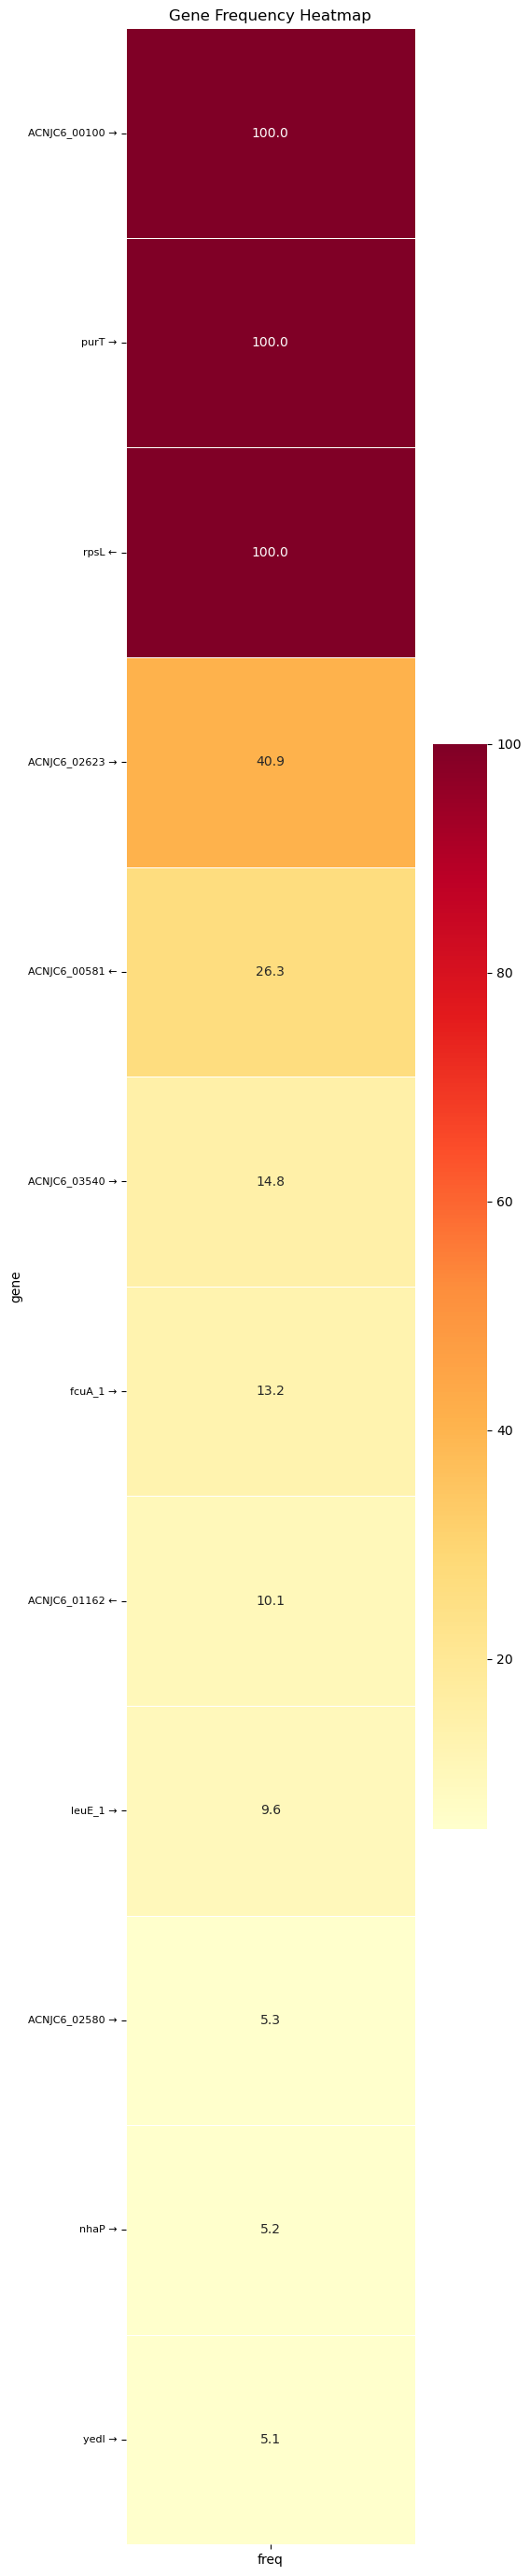

In [42]:
#PLOTTING ANCESTRAL MUTATIONS
df = Ancestral_mut

heatmap_data = pd.DataFrame()
heatmap_data['gene'] = df[('Predicted mutations', 'gene')]
heatmap_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))

#Sort the data by frequency
heatmap_data_sorted = heatmap_data.sort_values(by='freq', ascending=False)
pivot_data = heatmap_data_sorted.pivot_table(index='gene', values='freq')
row_order = pivot_data.sort_values(by='freq', ascending=False).index
pivot_data = pivot_data.loc[row_order]

#Plot
plt.figure(figsize=(5, 35))  # Adjust figure size as needed
sns.heatmap(pivot_data, cmap="YlOrRd", annot=True, fmt=".1f", linewidths=0.5)

plt.yticks(rotation=0)  # Ensure y-axis labels are horizontal
plt.yticks(fontsize=8)  # Adjust font size as needed
plt.title("Gene Frequency Heatmap")  # Add a title

# Show the plot
plt.show()


In [43]:
#MERGING ALL DATA FOR HEATMAP VISUALISATION
ancestral_data = pd.DataFrame()
ancestral_data['gene'] = Ancestral_mut[('Predicted mutations','gene')]
ancestral_data['freq'] = pd.to_numeric(Ancestral_mut[('Predicted mutations','freq')].str.rstrip('%'))
ancestral_data['dataset'] = 'Ancestral'

data_frames = [ancestral_data]

#Iterate through BAMono_mut
for folder, df in BAMono_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)

#Iterate through BABen60Mix_mut
for folder, df in BABen60Mix_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)
    
#Iterate through BAMix_mut
for folder, df in BAMix_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)

# Combine datasets
combined_df = pd.concat(data_frames, ignore_index=True)
combined_df.reset_index(drop=True, inplace=True)

pivot_table = combined_df.pivot_table(index='gene', columns='dataset', values='freq', aggfunc='mean')

desired_order = ['Ancestral',
                 'Aj_BA_Aj1_T07','Aj_BA_Aj1_T14','Aj_BA_Aj1_T21','Aj_BA_Aj1_T30',
                 'Aj_BA_Aj2_T07','Aj_BA_Aj2_T14','Aj_BA_Aj2_T21','Aj_BA_Aj2_T30',
                 'Aj_BA_Aj3_T07','Aj_BA_Aj3_T14','Aj_BA_Aj3_T21','Aj_BA_Aj3_T30',
                 'Aj_BA_Aj4_T07','Aj_BA_Aj4_T14','Aj_BA_Aj4_T21','Aj_BA_Aj4_T30',
                 'Aj_BA_Aj5_T07','Aj_BA_Aj5_T14','Aj_BA_Aj5_T21','Aj_BA_Aj5_T30',
                 'Aj_BA_Aj6_T07','Aj_BA_Aj6_T14','Aj_BA_Aj6_T21','Aj_BA_Aj6_T30',
                 'Aj_BABen60_Mix1_T07','Aj_BABen60_Mix1_T14','Aj_BABen60_Mix1_T21','Aj_BABen60_Mix1_T30',
                 'Aj_BABen60_Mix2_T07','Aj_BABen60_Mix2_T14','Aj_BABen60_Mix2_T21','Aj_BABen60_Mix2_T30',
                 'Aj_BABen60_Mix3_T07','Aj_BABen60_Mix3_T14','Aj_BABen60_Mix3_T21','Aj_BABen60_Mix3_T30',
                 'Aj_BABen60_Mix4_T07','Aj_BABen60_Mix4_T14','Aj_BABen60_Mix4_T21','Aj_BABen60_Mix4_T30',
                 'Aj_BABen60_Mix5_T07','Aj_BABen60_Mix5_T14','Aj_BABen60_Mix5_T21','Aj_BABen60_Mix5_T30',
                 'Aj_BABen60_Mix6_T07','Aj_BABen60_Mix6_T14','Aj_BABen60_Mix6_T21','Aj_BABen60_Mix6_T30',
                 'Aj_BA_Mix1_T07','Aj_BA_Mix1_T14','Aj_BA_Mix1_T21','Aj_BA_Mix1_T30',
                 'Aj_BA_Mix2_T07','Aj_BA_Mix2_T14','Aj_BA_Mix2_T21','Aj_BA_Mix2_T30',
                 'Aj_BA_Mix3_T07','Aj_BA_Mix3_T14','Aj_BA_Mix3_T21','Aj_BA_Mix3_T30',
                 'Aj_BA_Mix4_T07','Aj_BA_Mix4_T14','Aj_BA_Mix4_T21','Aj_BA_Mix4_T30',
                 'Aj_BA_Mix5_T07','Aj_BA_Mix5_T14','Aj_BA_Mix5_T21','Aj_BA_Mix5_T30',
                 'Aj_BA_Mix6_T07','Aj_BA_Mix6_T14','Aj_BA_Mix6_T21','Aj_BA_Mix6_T30'
                ] 
pivot_table = pivot_table[desired_order]

# Reorder rows based on the frequency values in the 'Ancestral' dataset
ancestral_freq = pivot_table['Ancestral']
row_order = ancestral_freq.sort_values(ascending=False).index
pivot_table = pivot_table.loc[row_order]

plt.figure(figsize=(50, 200))  # Adjust the figure size as needed
ax = sns.heatmap(pivot_table, cmap="YlOrRd", annot=False, fmt=".1f", linewidths=0.5)

plt.yticks(rotation=0)  
plt.yticks(fontsize=8)
plt.xlabel("dataset")
plt.ylabel("Gene")
plt.title("Gene Frequency Heatmap")

plt.savefig('/Users/thibaultrosazza/Documents/Python/Results/Evolution_experiment/GeneMut_Aj_heatmap.png', dpi=300)
plt.savefig('/Users/thibaultrosazza/Documents/Python/Results/Evolution_experiment/GeneMut_Aj_heatmap.svg', dpi=300)
plt.show()

## Mutations above 10%

In [44]:
#IMPORT OUTPUT DATA FROM BRESEQ

''' Data for Ancestral to the reference genome '''
tables = pd.read_html('/Users/thibaultrosazza/Cluster_mount/AjC6_to_AjAnc/output/index.html')
Ancestral_mut = tables[1]  # This get the Predicted mutations table
Ancestral_mut.tail()

''' Data for BAMix to the reference genome '''
root_dir = '/Users/thibaultrosazza/Cluster_mount/Aj_to_BAMix/'

data_dict = {}

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    
    if os.path.isdir(folder_path):
        index_file = os.path.join(folder_path, 'output', 'index.html')
        
        if os.path.exists(index_file):
            tables = pd.read_html(index_file)
            data_dict[folder_name] = tables[1]           
            print(f"Parsed table from {folder_name}")

BAMix_mut = data_dict

''' Data for BABen60Mix to the reference genome '''
root_dir = '/Users/thibaultrosazza/Cluster_mount/Aj_to_BABen60Mix/'

data_dict = {}

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    
    if os.path.isdir(folder_path):
        index_file = os.path.join(folder_path, 'output', 'index.html')
        
        if os.path.exists(index_file):
            tables = pd.read_html(index_file)
            data_dict[folder_name] = tables[1]           
            print(f"Parsed table from {folder_name}")

BABen60Mix_mut = data_dict

''' Data for BABen60Mono to the reference genome '''
root_dir = '/Users/thibaultrosazza/Cluster_mount/Aj_to_BAMono/'

data_dict = {}

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    
    if os.path.isdir(folder_path):
        index_file = os.path.join(folder_path, 'output', 'index.html')
        
        if os.path.exists(index_file):
            tables = pd.read_html(index_file)
            data_dict[folder_name] = tables[1]           
            print(f"Parsed table from {folder_name}")

BAMono_mut = data_dict

Parsed table from Aj_BA_Mix2_T14
Parsed table from Aj_BA_Mix3_T14
Parsed table from Aj_BA_Mix1_T14
Parsed table from Aj_BA_Mix4_T14
Parsed table from Aj_BA_Mix5_T14
Parsed table from Aj_BA_Mix6_T14
Parsed table from Aj_BA_Mix6_T07
Parsed table from Aj_BA_Mix5_T30
Parsed table from Aj_BA_Mix4_T30
Parsed table from Aj_BA_Mix5_T07
Parsed table from Aj_BA_Mix6_T30
Parsed table from Aj_BA_Mix4_T07
Parsed table from Aj_BA_Mix3_T30
Parsed table from Aj_BA_Mix1_T07
Parsed table from Aj_BA_Mix2_T30
Parsed table from Aj_BA_Mix3_T07
Parsed table from Aj_BA_Mix2_T07
Parsed table from Aj_BA_Mix1_T30
Parsed table from Aj_BA_Mix3_T21
Parsed table from Aj_BA_Mix2_T21
Parsed table from Aj_BA_Mix1_T21
Parsed table from Aj_BA_Mix5_T21
Parsed table from Aj_BA_Mix4_T21
Parsed table from Aj_BA_Mix6_T21
Parsed table from Aj_BABen60_Mix1_T07
Parsed table from Aj_BABen60_Mix2_T30
Parsed table from Aj_BABen60_Mix3_T30
Parsed table from Aj_BABen60_Mix2_T07
Parsed table from Aj_BABen60_Mix1_T30
Parsed table from 

In [45]:
for index, row in Ancestral_mut:
    Ancestral_mut[('Predicted mutations', 'freq_numeric')] = Ancestral_mut[('Predicted mutations', 'freq')].str.replace('%', '').astype(float) / 100.0
    Ancestral_mut = Ancestral_mut.loc[Ancestral_mut[('Predicted mutations', 'freq_numeric')] >= 0.10]
    Ancestral_mut = Ancestral_mut.drop(columns=[('Predicted mutations', 'freq_numeric')])

for folder, df in BAMono_mut.items():
    df[('Predicted mutations', 'freq_numeric')] = df[('Predicted mutations', 'freq')].str.replace('%', '').astype(float) / 100.0
    df = df.loc[df[('Predicted mutations', 'freq_numeric')] >= 0.10]
    df = df.drop(columns=[('Predicted mutations', 'freq_numeric')])
    BAMono_mut[folder] = df

for folder, df in BAMix_mut.items():
    df[('Predicted mutations', 'freq_numeric')] = df[('Predicted mutations', 'freq')].str.replace('%', '').astype(float) / 100.0
    df = df.loc[df[('Predicted mutations', 'freq_numeric')] >= 0.10]
    df = df.drop(columns=[('Predicted mutations', 'freq_numeric')])
    BAMix_mut[folder] = df

for folder, df in BABen60Mix_mut.items():
    df[('Predicted mutations', 'freq_numeric')] = df[('Predicted mutations', 'freq')].str.replace('%', '').astype(float) / 100.0
    df = df.loc[df[('Predicted mutations', 'freq_numeric')] >= 0.10]
    df = df.drop(columns=[('Predicted mutations', 'freq_numeric')])
    BABen60Mix_mut[folder] = df

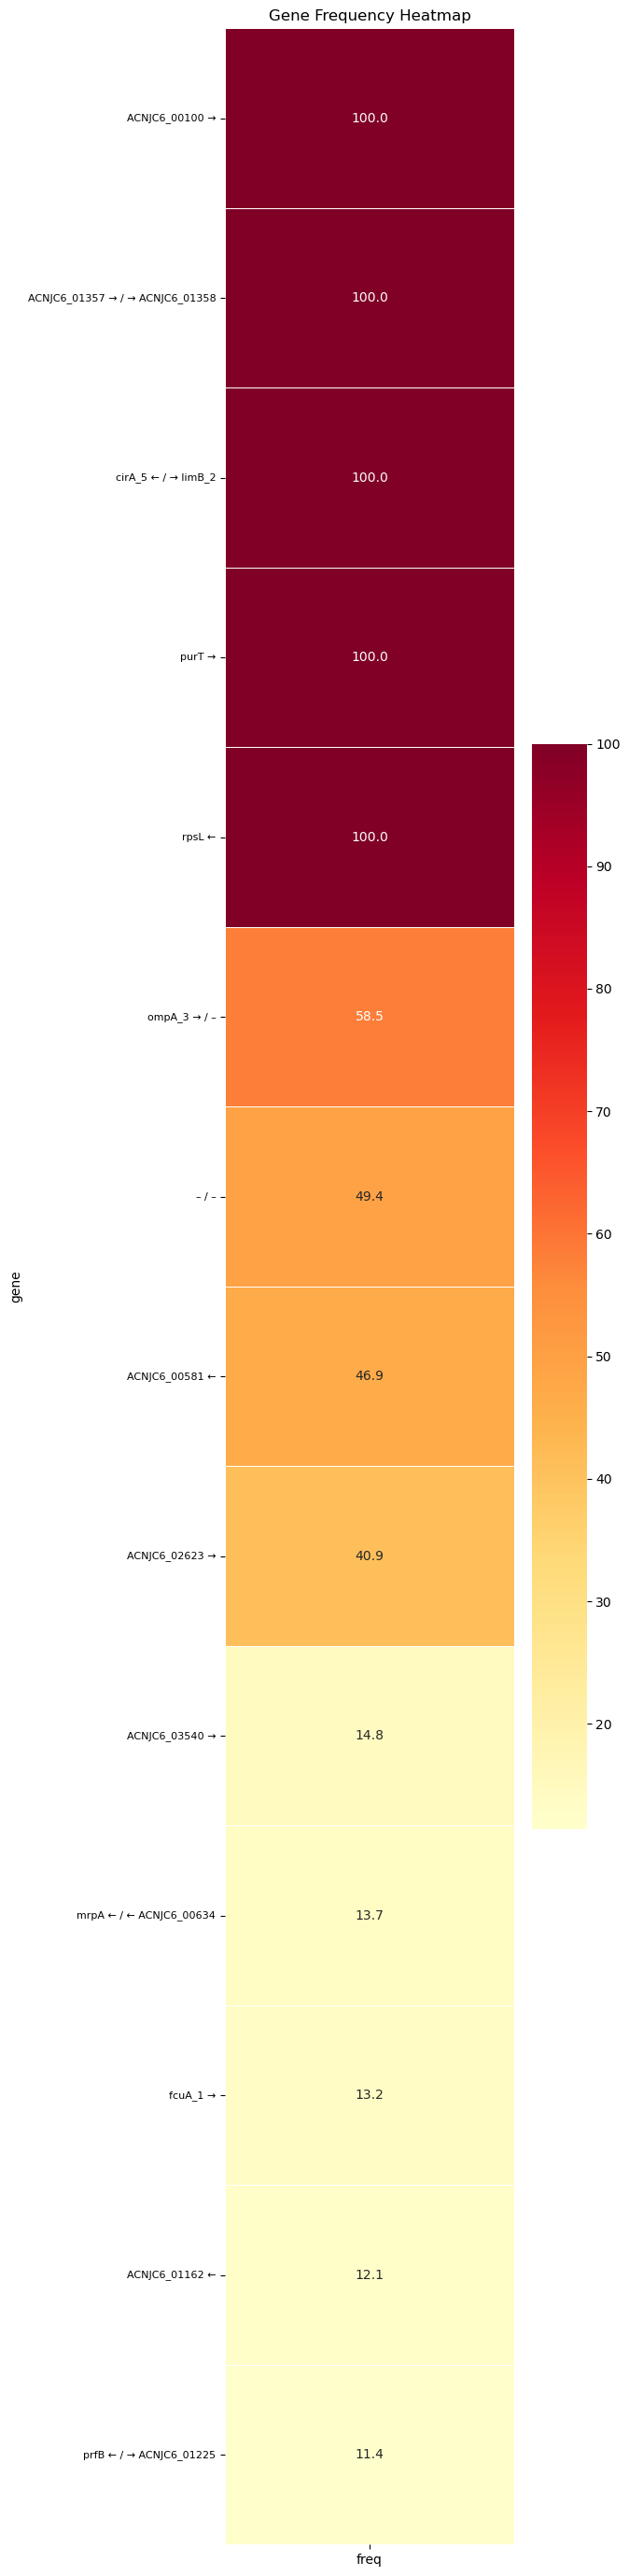

In [46]:
#PLOTTING ANCESTRAL MUTATIONS
df = Ancestral_mut

heatmap_data = pd.DataFrame()
heatmap_data['gene'] = df[('Predicted mutations', 'gene')]
heatmap_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))

#Sort the data by frequency
heatmap_data_sorted = heatmap_data.sort_values(by='freq', ascending=False)
pivot_data = heatmap_data_sorted.pivot_table(index='gene', values='freq')
row_order = pivot_data.sort_values(by='freq', ascending=False).index
pivot_data = pivot_data.loc[row_order]

#Plot
plt.figure(figsize=(5, 35))  # Adjust figure size as needed
sns.heatmap(pivot_data, cmap="YlOrRd", annot=True, fmt=".1f", linewidths=0.5)

plt.yticks(rotation=0)  # Ensure y-axis labels are horizontal
plt.yticks(fontsize=8)  # Adjust font size as needed
plt.title("Gene Frequency Heatmap")  # Add a title

# Show the plot
plt.show()

In [47]:
#MERGING ALL DATA FOR HEATMAP VISUALISATION
ancestral_data = pd.DataFrame()
ancestral_data['gene'] = Ancestral_mut[('Predicted mutations','gene')]
ancestral_data['freq'] = pd.to_numeric(Ancestral_mut[('Predicted mutations','freq')].str.rstrip('%'))
ancestral_data['dataset'] = 'Ancestral'

data_frames = [ancestral_data]

#Iterate through BAMono_mut
for folder, df in BAMono_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)

#Iterate through BABen60Mix_mut
for folder, df in BABen60Mix_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)
    
#Iterate through BAMix_mut
for folder, df in BAMix_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)

# Combine datasets
combined_df = pd.concat(data_frames, ignore_index=True)
combined_df.reset_index(drop=True, inplace=True)

pivot_table = combined_df.pivot_table(index='gene', columns='dataset', values='freq', aggfunc='mean')

desired_order = ['Ancestral',
                 'Aj_BA_Aj1_T07','Aj_BA_Aj1_T14','Aj_BA_Aj1_T21','Aj_BA_Aj1_T30',
                 'Aj_BA_Aj2_T07','Aj_BA_Aj2_T14','Aj_BA_Aj2_T21','Aj_BA_Aj2_T30',
                 'Aj_BA_Aj3_T07','Aj_BA_Aj3_T14','Aj_BA_Aj3_T21','Aj_BA_Aj3_T30',
                 'Aj_BA_Aj4_T07','Aj_BA_Aj4_T14','Aj_BA_Aj4_T21','Aj_BA_Aj4_T30',
                 'Aj_BA_Aj5_T07','Aj_BA_Aj5_T14','Aj_BA_Aj5_T21','Aj_BA_Aj5_T30',
                 'Aj_BA_Aj6_T07','Aj_BA_Aj6_T14','Aj_BA_Aj6_T21','Aj_BA_Aj6_T30',
                 'Aj_BABen60_Mix1_T07','Aj_BABen60_Mix1_T14','Aj_BABen60_Mix1_T21','Aj_BABen60_Mix1_T30',
                 'Aj_BABen60_Mix2_T07','Aj_BABen60_Mix2_T14','Aj_BABen60_Mix2_T21','Aj_BABen60_Mix2_T30',
                 'Aj_BABen60_Mix3_T07','Aj_BABen60_Mix3_T14','Aj_BABen60_Mix3_T21','Aj_BABen60_Mix3_T30',
                 'Aj_BABen60_Mix4_T07','Aj_BABen60_Mix4_T14','Aj_BABen60_Mix4_T21','Aj_BABen60_Mix4_T30',
                 'Aj_BABen60_Mix5_T07','Aj_BABen60_Mix5_T14','Aj_BABen60_Mix5_T21','Aj_BABen60_Mix5_T30',
                 'Aj_BABen60_Mix6_T07','Aj_BABen60_Mix6_T14','Aj_BABen60_Mix6_T21','Aj_BABen60_Mix6_T30',
                 'Aj_BA_Mix1_T07','Aj_BA_Mix1_T14','Aj_BA_Mix1_T21','Aj_BA_Mix1_T30',
                 'Aj_BA_Mix2_T07','Aj_BA_Mix2_T14','Aj_BA_Mix2_T21','Aj_BA_Mix2_T30',
                 'Aj_BA_Mix3_T07','Aj_BA_Mix3_T14','Aj_BA_Mix3_T21','Aj_BA_Mix3_T30',
                 'Aj_BA_Mix4_T07','Aj_BA_Mix4_T14','Aj_BA_Mix4_T21','Aj_BA_Mix4_T30',
                 'Aj_BA_Mix5_T07','Aj_BA_Mix5_T14','Aj_BA_Mix5_T21','Aj_BA_Mix5_T30',
                 'Aj_BA_Mix6_T07','Aj_BA_Mix6_T14','Aj_BA_Mix6_T21','Aj_BA_Mix6_T30'
                ] 
pivot_table = pivot_table[desired_order]

# Reorder rows based on the frequency values in the 'Ancestral' dataset
ancestral_freq = pivot_table['Ancestral']
row_order = ancestral_freq.sort_values(ascending=False).index
pivot_table = pivot_table.loc[row_order]

plt.figure(figsize=(50, 200))  # Adjust the figure size as needed
ax = sns.heatmap(pivot_table, cmap="YlOrRd", annot=False, fmt=".1f", linewidths=0.5)

plt.yticks(rotation=0)  
plt.yticks(fontsize=8)
plt.xlabel("dataset")
plt.ylabel("Gene")
plt.title("Gene Frequency Heatmap")

plt.savefig('/Users/thibaultrosazza/Documents/Python/Results/Evolution_experiment/Above10AllMut_Aj_heatmap.png', dpi=300)
plt.savefig('/Users/thibaultrosazza/Documents/Python/Results/Evolution_experiment/Above10AllMut_Aj_heatmap.svg', dpi=300)
plt.show()

## Without intergenic and above 10% mutations

In [48]:
#IMPORT OUTPUT DATA FROM BRESEQ

''' Data for Ancestral to the reference genome '''
tables = pd.read_html('/Users/thibaultrosazza/Cluster_mount/AjC6_to_AjAnc/output/index.html')
Ancestral_mut = tables[1]  # This get the Predicted mutations table
Ancestral_mut.tail()

''' Data for BAMix to the reference genome '''
root_dir = '/Users/thibaultrosazza/Cluster_mount/Aj_to_BAMix/'

data_dict = {}

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    
    if os.path.isdir(folder_path):
        index_file = os.path.join(folder_path, 'output', 'index.html')
        
        if os.path.exists(index_file):
            tables = pd.read_html(index_file)
            data_dict[folder_name] = tables[1]           
            print(f"Parsed table from {folder_name}")

BAMix_mut = data_dict

''' Data for BABen60Mix to the reference genome '''
root_dir = '/Users/thibaultrosazza/Cluster_mount/Aj_to_BABen60Mix/'

data_dict = {}

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    
    if os.path.isdir(folder_path):
        index_file = os.path.join(folder_path, 'output', 'index.html')
        
        if os.path.exists(index_file):
            tables = pd.read_html(index_file)
            data_dict[folder_name] = tables[1]           
            print(f"Parsed table from {folder_name}")

BABen60Mix_mut = data_dict

''' Data for BABen60Mono to the reference genome '''
root_dir = '/Users/thibaultrosazza/Cluster_mount/Aj_to_BAMono/'

data_dict = {}

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    
    if os.path.isdir(folder_path):
        index_file = os.path.join(folder_path, 'output', 'index.html')
        
        if os.path.exists(index_file):
            tables = pd.read_html(index_file)
            data_dict[folder_name] = tables[1]           
            print(f"Parsed table from {folder_name}")

BAMono_mut = data_dict

Parsed table from Aj_BA_Mix2_T14
Parsed table from Aj_BA_Mix3_T14
Parsed table from Aj_BA_Mix1_T14
Parsed table from Aj_BA_Mix4_T14
Parsed table from Aj_BA_Mix5_T14
Parsed table from Aj_BA_Mix6_T14
Parsed table from Aj_BA_Mix6_T07
Parsed table from Aj_BA_Mix5_T30
Parsed table from Aj_BA_Mix4_T30
Parsed table from Aj_BA_Mix5_T07
Parsed table from Aj_BA_Mix6_T30
Parsed table from Aj_BA_Mix4_T07
Parsed table from Aj_BA_Mix3_T30
Parsed table from Aj_BA_Mix1_T07
Parsed table from Aj_BA_Mix2_T30
Parsed table from Aj_BA_Mix3_T07
Parsed table from Aj_BA_Mix2_T07
Parsed table from Aj_BA_Mix1_T30
Parsed table from Aj_BA_Mix3_T21
Parsed table from Aj_BA_Mix2_T21
Parsed table from Aj_BA_Mix1_T21
Parsed table from Aj_BA_Mix5_T21
Parsed table from Aj_BA_Mix4_T21
Parsed table from Aj_BA_Mix6_T21
Parsed table from Aj_BABen60_Mix1_T07
Parsed table from Aj_BABen60_Mix2_T30
Parsed table from Aj_BABen60_Mix3_T30
Parsed table from Aj_BABen60_Mix2_T07
Parsed table from Aj_BABen60_Mix1_T30
Parsed table from 

In [49]:
for index, row in Ancestral_mut:
    Ancestral_mut[('Predicted mutations', 'freq_numeric')] = Ancestral_mut[('Predicted mutations', 'freq')].str.replace('%', '').astype(float) / 100.0
    Ancestral_mut = Ancestral_mut.loc[Ancestral_mut[('Predicted mutations', 'freq_numeric')] >= 0.10]
    Ancestral_mut = Ancestral_mut.drop(columns=[('Predicted mutations', 'freq_numeric')])

for folder, df in BAMono_mut.items():
    df[('Predicted mutations', 'freq_numeric')] = df[('Predicted mutations', 'freq')].str.replace('%', '').astype(float) / 100.0
    df = df.loc[df[('Predicted mutations', 'freq_numeric')] >= 0.10]
    df = df.drop(columns=[('Predicted mutations', 'freq_numeric')])
    BAMono_mut[folder] = df

for folder, df in BAMix_mut.items():
    df[('Predicted mutations', 'freq_numeric')] = df[('Predicted mutations', 'freq')].str.replace('%', '').astype(float) / 100.0
    df = df.loc[df[('Predicted mutations', 'freq_numeric')] >= 0.10]
    df = df.drop(columns=[('Predicted mutations', 'freq_numeric')])
    BAMix_mut[folder] = df

for folder, df in BABen60Mix_mut.items():
    df[('Predicted mutations', 'freq_numeric')] = df[('Predicted mutations', 'freq')].str.replace('%', '').astype(float) / 100.0
    df = df.loc[df[('Predicted mutations', 'freq_numeric')] >= 0.10]
    df = df.drop(columns=[('Predicted mutations', 'freq_numeric')])
    BABen60Mix_mut[folder] = df

In [50]:
for index, row in Ancestral_mut:
    Ancestral_mut = Ancestral_mut.loc[~Ancestral_mut[('Predicted mutations', 'annotation')].str.contains('intergenic', na=False)]
    
for folder, df in BAMono_mut.items():
    df = df.loc[~df[('Predicted mutations', 'annotation')].str.contains('intergenic', na=False)]
    BAMono_mut[folder] = df
    
for folder, df in BABen60Mix_mut.items():
    df = df.loc[~df[('Predicted mutations', 'annotation')].str.contains('intergenic', na=False)]
    BABen60Mix_mut[folder] = df

for folder, df in BAMix_mut.items():
    df = df.loc[~df[('Predicted mutations', 'annotation')].str.contains('intergenic', na=False)]
    BAMix_mut[folder] = df

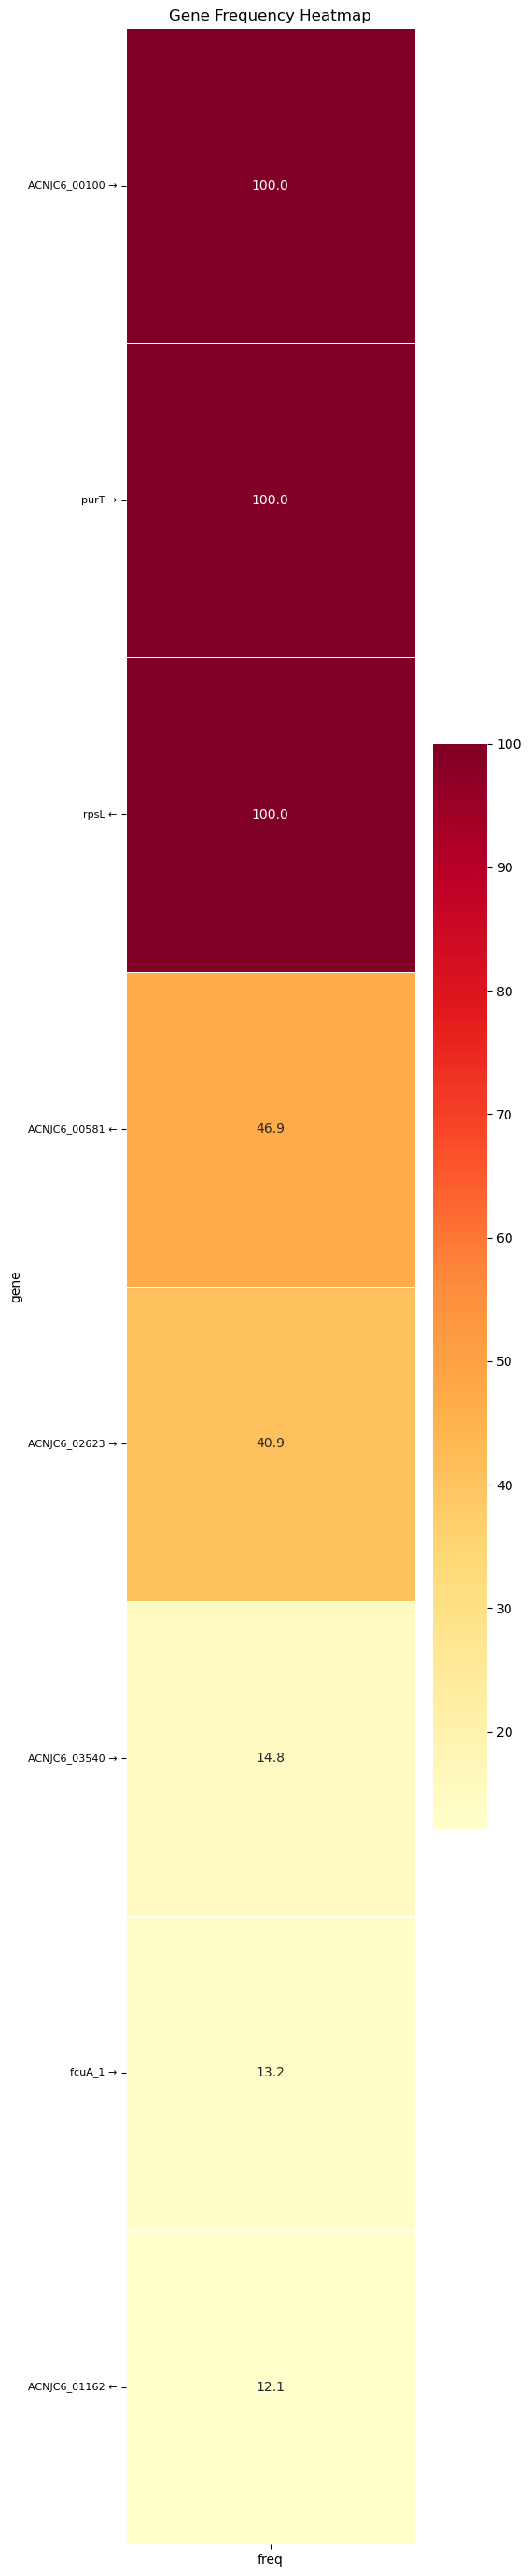

In [51]:
#PLOTTING ANCESTRAL MUTATIONS
df = Ancestral_mut

heatmap_data = pd.DataFrame()
heatmap_data['gene'] = df[('Predicted mutations', 'gene')]
heatmap_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))

#Sort the data by frequency
heatmap_data_sorted = heatmap_data.sort_values(by='freq', ascending=False)
pivot_data = heatmap_data_sorted.pivot_table(index='gene', values='freq')
row_order = pivot_data.sort_values(by='freq', ascending=False).index
pivot_data = pivot_data.loc[row_order]

#Plot
plt.figure(figsize=(5, 35))  # Adjust figure size as needed
sns.heatmap(pivot_data, cmap="YlOrRd", annot=True, fmt=".1f", linewidths=0.5)

plt.yticks(rotation=0)  # Ensure y-axis labels are horizontal
plt.yticks(fontsize=8)  # Adjust font size as needed
plt.title("Gene Frequency Heatmap")  # Add a title

# Show the plot
plt.show()


In [52]:
#MERGING ALL DATA FOR HEATMAP VISUALISATION
ancestral_data = pd.DataFrame()
ancestral_data['gene'] = Ancestral_mut[('Predicted mutations','gene')]
ancestral_data['freq'] = pd.to_numeric(Ancestral_mut[('Predicted mutations','freq')].str.rstrip('%'))
ancestral_data['dataset'] = 'Ancestral'

data_frames = [ancestral_data]

#Iterate through BAMono_mut
for folder, df in BAMono_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)

#Iterate through BABen60Mix_mut
for folder, df in BABen60Mix_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)
    
#Iterate through BAMix_mut
for folder, df in BAMix_mut.items():
    folder_data = pd.DataFrame()
    folder_data['gene'] = df[('Predicted mutations', 'gene')]
    folder_data['freq'] = pd.to_numeric(df[('Predicted mutations', 'freq')].str.rstrip('%'))
    folder_data['dataset'] = folder

    data_frames.append(folder_data)

# Combine datasets
combined_df = pd.concat(data_frames, ignore_index=True)
combined_df.reset_index(drop=True, inplace=True)

pivot_table = combined_df.pivot_table(index='gene', columns='dataset', values='freq', aggfunc='mean')

desired_order = ['Ancestral',
                 'Aj_BA_Aj1_T07','Aj_BA_Aj1_T14','Aj_BA_Aj1_T21','Aj_BA_Aj1_T30',
                 'Aj_BA_Aj2_T07','Aj_BA_Aj2_T14','Aj_BA_Aj2_T21','Aj_BA_Aj2_T30',
                 'Aj_BA_Aj3_T07','Aj_BA_Aj3_T14','Aj_BA_Aj3_T21','Aj_BA_Aj3_T30',
                 'Aj_BA_Aj4_T07','Aj_BA_Aj4_T14','Aj_BA_Aj4_T21','Aj_BA_Aj4_T30',
                 'Aj_BA_Aj5_T07','Aj_BA_Aj5_T14','Aj_BA_Aj5_T21','Aj_BA_Aj5_T30',
                 'Aj_BA_Aj6_T07','Aj_BA_Aj6_T14','Aj_BA_Aj6_T21','Aj_BA_Aj6_T30',
                 'Aj_BABen60_Mix1_T07','Aj_BABen60_Mix1_T14','Aj_BABen60_Mix1_T21','Aj_BABen60_Mix1_T30',
                 'Aj_BABen60_Mix2_T07','Aj_BABen60_Mix2_T14','Aj_BABen60_Mix2_T21','Aj_BABen60_Mix2_T30',
                 'Aj_BABen60_Mix3_T07','Aj_BABen60_Mix3_T14','Aj_BABen60_Mix3_T21','Aj_BABen60_Mix3_T30',
                 'Aj_BABen60_Mix4_T07','Aj_BABen60_Mix4_T14','Aj_BABen60_Mix4_T21','Aj_BABen60_Mix4_T30',
                 'Aj_BABen60_Mix5_T07','Aj_BABen60_Mix5_T14','Aj_BABen60_Mix5_T21','Aj_BABen60_Mix5_T30',
                 'Aj_BABen60_Mix6_T07','Aj_BABen60_Mix6_T14','Aj_BABen60_Mix6_T21','Aj_BABen60_Mix6_T30',
                 'Aj_BA_Mix1_T07','Aj_BA_Mix1_T14','Aj_BA_Mix1_T21','Aj_BA_Mix1_T30',
                 'Aj_BA_Mix2_T07','Aj_BA_Mix2_T14','Aj_BA_Mix2_T21','Aj_BA_Mix2_T30',
                 'Aj_BA_Mix3_T07','Aj_BA_Mix3_T14','Aj_BA_Mix3_T21','Aj_BA_Mix3_T30',
                 'Aj_BA_Mix4_T07','Aj_BA_Mix4_T14','Aj_BA_Mix4_T21','Aj_BA_Mix4_T30',
                 'Aj_BA_Mix5_T07','Aj_BA_Mix5_T14','Aj_BA_Mix5_T21','Aj_BA_Mix5_T30',
                 'Aj_BA_Mix6_T07','Aj_BA_Mix6_T14','Aj_BA_Mix6_T21','Aj_BA_Mix6_T30'
                ] 
pivot_table = pivot_table[desired_order]

# Reorder rows based on the frequency values in the 'Ancestral' dataset
ancestral_freq = pivot_table['Ancestral']
row_order = ancestral_freq.sort_values(ascending=False).index
pivot_table = pivot_table.loc[row_order]

plt.figure(figsize=(50, 200))  # Adjust the figure size as needed
ax = sns.heatmap(pivot_table, cmap="YlOrRd", annot=False, fmt=".1f", linewidths=0.5)

plt.yticks(rotation=0)  
plt.yticks(fontsize=8)
plt.xlabel("dataset")
plt.ylabel("Gene")
plt.title("Gene Frequency Heatmap")

plt.savefig('/Users/thibaultrosazza/Documents/Python/Results/Evolution_experiment/Above10GeneMut_Aj_heatmap.png', dpi=300)
plt.savefig('/Users/thibaultrosazza/Documents/Python/Results/Evolution_experiment/Above10GeneMut_Aj_heatmap.svg', dpi=300)
plt.show()